# Vierparameter-logistische dosis-responscurvefitting met PROC NLIN

## Samenvatting

Dit notebook fit een vierparameter-logistisch (4PL) dosis-responsmodel op een synthetische celgebaseerde potentie-bioassay met **PROC NLIN**, en schat daarbij de onderste en bovenste asymptoten, de EC50 (halfmaximale effectieve concentratie) en de Hill-helling. Het 4PL is het standaardmodel voor relatieve-potentie-assays in de geneesmiddelenontwikkeling, en het notebook doorloopt de modelspecificatie, het begrenzen van parameters, convergentiediagnostiek en het over de waargenomen concentratie-responsgegevens heen leggen van de gefitte sigmoïde.

## Gegevensbronnen

Het notebook genereert inline één synthetische dataset; er wordt geen externe of netwerkinvoer gebruikt.

**`assay` — synthetische celgebaseerde potentie-bioassay (24 rijen)**

| Variabele | Type | Omschrijving |
|----------|------|-------------|
| `lot` | num | Werkzame-stoflot (1-3); drie herhaalde runs van de verdunningsreeks |
| `dose` | num | Verbindingsconcentratie in nmol/L over een 8-punts seriële verdunning (0.1 tot ~1000) |
| `logdose` | num | Logaritme met grondtal 10 van `dose`, gebruikt om te plotten op de conventionele log-concentratie-as |
| `response` | num | Gemeten assaysignaal (percentage van de maximale respons), gegenereerd uit een echte 4PL-curve (bottom=5, top=100, EC50=25 nmol/L, Hill-helling=1.2) plus proportionele Gaussische ruis |

De echte genererende parameters zijn vastgelegd in de DATA step, zodat de teruggevonden NLIN-schattingen kunnen worden getoetst aan de bekende werkelijkheid.

# Vierparameter-logistische dosis-responsfitting

In farmaceutische potentie- en bioactiviteitsassays is de relatie tussen verbindingsconcentratie en gemeten respons karakteristiek sigmoïdaal op een log-concentratieschaal. Het **vierparameter-logistische (4PL)**-model is het standaardhulpmiddel om zulke curves samen te vatten:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

waarbij

- **A** = onderste asymptoot (respons bij oneindige verdunning / basislijnsignaal),
- **D** = bovenste asymptoot (maximale respons bij verzadigende concentratie),
- **C** = de **EC50**, de concentratie die de halfmaximale respons oplevert (het buigpunt en de primaire potentie-uitkomst),
- **B** = de **Hill-helling**, die de steilheid van de overgang bepaalt.

Dit model is niet-lineair in zijn parameters, dus fitten we het met iteratieve kleinste kwadraten via `PROC NLIN`. Hieronder simuleren we een realistische achtpunts verdunningsreeks in triplo, fitten we de 4PL-curve, begrenzen we de parameters tot fysisch zinvolle gebieden, inspecteren we convergentie- en fitdiagnostiek, en leggen we de gefitte curve over de gegevens heen.

## Stap 1 — Simuleer een celgebaseerde potentie-bioassay

We genereren een synthetische dataset uit een *bekende* 4PL-curve (bottom = 5, top = 100, EC50 = 25 nmol/L, Hill-helling = 1.2), zodat de parameters die NLIN terugvindt kunnen worden getoetst aan de werkelijkheid. Drie lots krijgen elk dezelfde achtpunts seriële verdunning (elke stap een 3.5-voudige verdunning), met daarbovenop proportionele Gaussische meetruis. Een vaste `streaminit`-seed maakt de simulatie reproduceerbaar.

In [1]:
GEGEVENS assay;
    CALL streaminit(40521);

    /* Werkelijke 4PL-parameters gebruikt om de gegevens te genereren */
    A_true   = 5;      /* onderste asymptoot (baseline)        */
    D_true   = 100;    /* bovenste asymptoot (max respons)     */
    C_true   = 25;     /* EC50 in nmol/L                       */
    B_true   = 1.2;    /* Hill-helling                         */

    DOE lot = 1 TOT 3;
        /* Achtpunts seriële verdunning, 3,5-voudige stappen */
        dose = 0.30;
        DOE point = 1 TOT 8;
            dose = dose * 3.5;

            /* Ruisvrije gemiddelde 4PL-respons */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportionele + additieve Gaussische assayruis */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            UITVOER;
        EINDE;
    EINDE;

    BEWAREN lot dose logdose response;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=assay;
    VOLGENS dose lot;
UITVOEREN;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Stap 2 — Visualiseer de ruwe concentratie-responsgegevens

Vóór het fitten plotten we de respons tegen log10(dose) om de verwachte sigmoïdale vorm te bevestigen en om ruwe startwaarden af te lezen: de curve bereikt een ondergrens rond 5, een plateau rond 100, en het middelpunt (halfmaximale respons) ligt rond log10(25) ≈ 1.4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


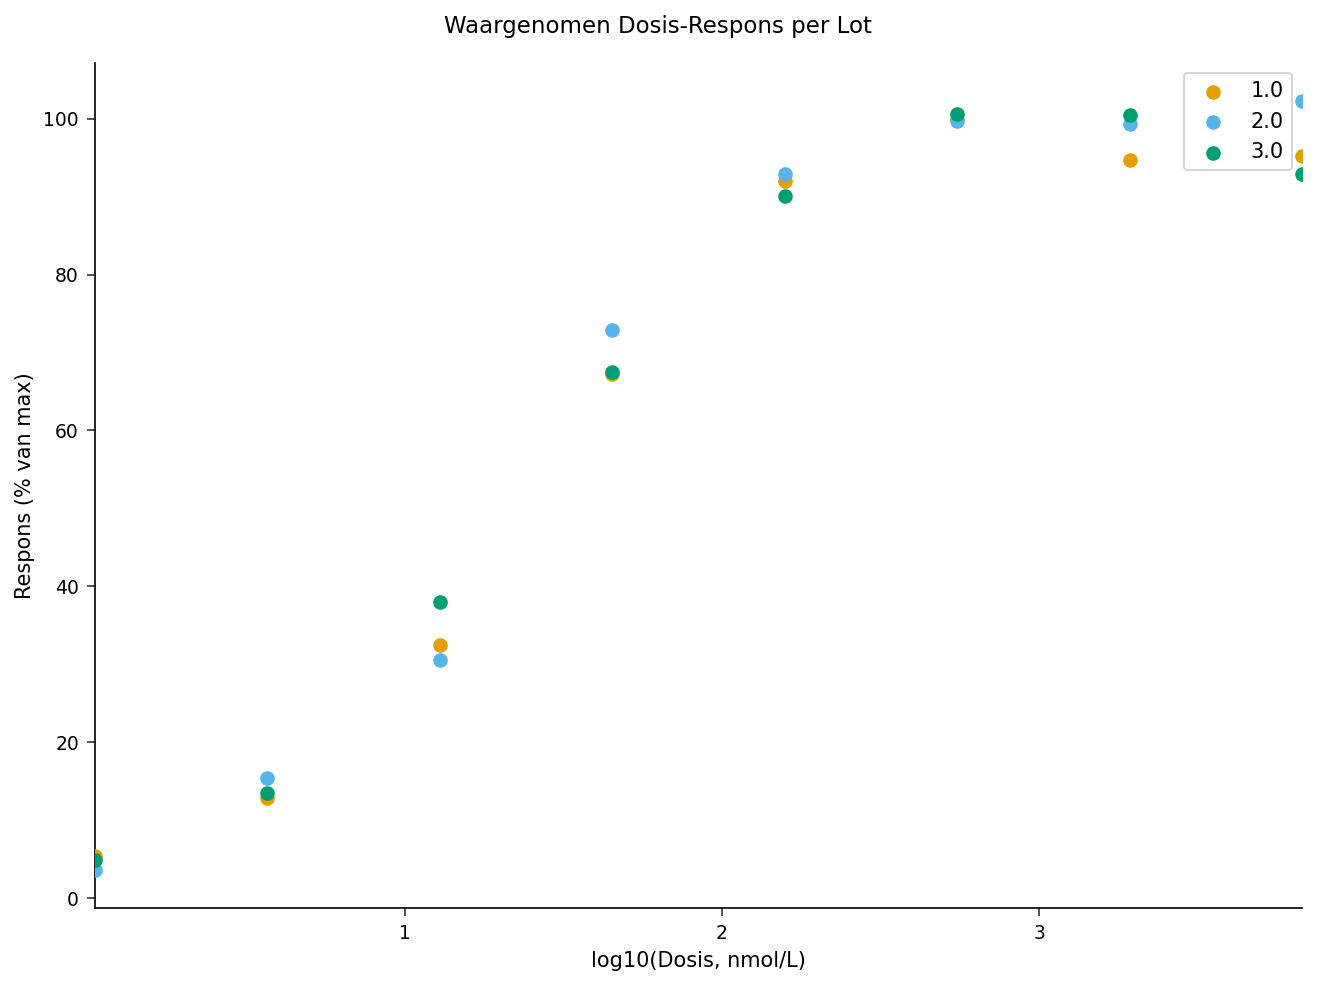

In [2]:
PROCEDURE SGPLOT GEGEVENS=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS label='log10(Dosis, nmol/L)';
    YAXIS label='Respons (% van max)';
    TITEL 'Waargenomen Dosis-Respons per Lot';
UITVOEREN;
TITEL;


## Stap 3 — Fit het 4PL-model met PROC NLIN

We declareren startwaarden met `PARMS` (afgeleid uit de spreidingsplot), definiëren het 4PL-gemiddelde in een tussentijdse toewijzing, en geven dit door aan de `MODEL`-statement. Fysisch zinvolle `BOUNDS` houden de asymptoten geordend en de EC50 en helling positief, wat de Gauss-Newton-iteraties stabiliseert. De `OUTPUT`-statement bewaart voorspelde waarden, residuen en betrouwbaarheidsgrenzen voor latere diagnostiek, en `PLOTS=` vraagt de fit- en diagnostiekpanelen aan.

In [3]:
PROCEDURE nlin GEGEVENS=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Houd de parameters in fysisch zinvolle gebieden */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Vierparameter-logistische gemiddelde respons (inline: PROC NLIN
       van Jenner ondersteunt nog niet het verwijzen naar een tussentijdse
       programmastatement-variabele in het MODEL — zie tests/400986 —
       daarom werken we de noemer hier inline uit) */
    MODEL response = D + (A - D) / (1 + (dose / C) ** B);

    LABEL response='Respons (% van max)' dose='Dosis (nmol/L)';

    UITVOER out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
UITVOEREN;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/4aab2b71-161d-401f-9540-904815f23e52/fit4pl.avro


## Stap 4 — Rapporteer de geschatte EC50 en curvekenmerken

Het `OUTEST=`-mechanisme is handig, maar voor een snelle potentie-uitkomst vatten we de gefitte curve rechtstreeks samen. Hier zetten we de gefitte waarden bij elke dosis naast de waargenomen responsen om te bevestigen dat het model de gegevens over het volledige verdunningsbereik volgt.

In [4]:
PROCEDURE GEMIDDELDEN GEGEVENS=fit4pl mean std MIN MAX maxdec=3;
    KLASSE dose;
    VARIABELE response pred resid;
    label dose='Dosis (nmol/L)'
          response='Respons (% van max)'
          pred='Voorspelde Respons'
          resid='Residu';
    TITEL 'Waargenomen versus Gefitte Respons per Dosis';
UITVOEREN;
TITEL;


                                      Waargenomen versus Gefitte Respons per Dosis                                      

                                                  The MEANS Procedure

                                   Analysis Variable : RESPONSE Respons (% van max)

                                           N
                       Dosis (nmol/L)    Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.39


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 5 — Leg de gefitte 4PL-curve over de waargenomen gegevens

Een dicht voorspellingsraster levert een gladde gefitte sigmoïde op. We combineren de gladde curve met de per-dosis gemiddelde gefitte waarden en de betrouwbaarheidsband, en leggen vervolgens alles over de waargenomen punten heen om de kwaliteit van de fit visueel te beoordelen.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


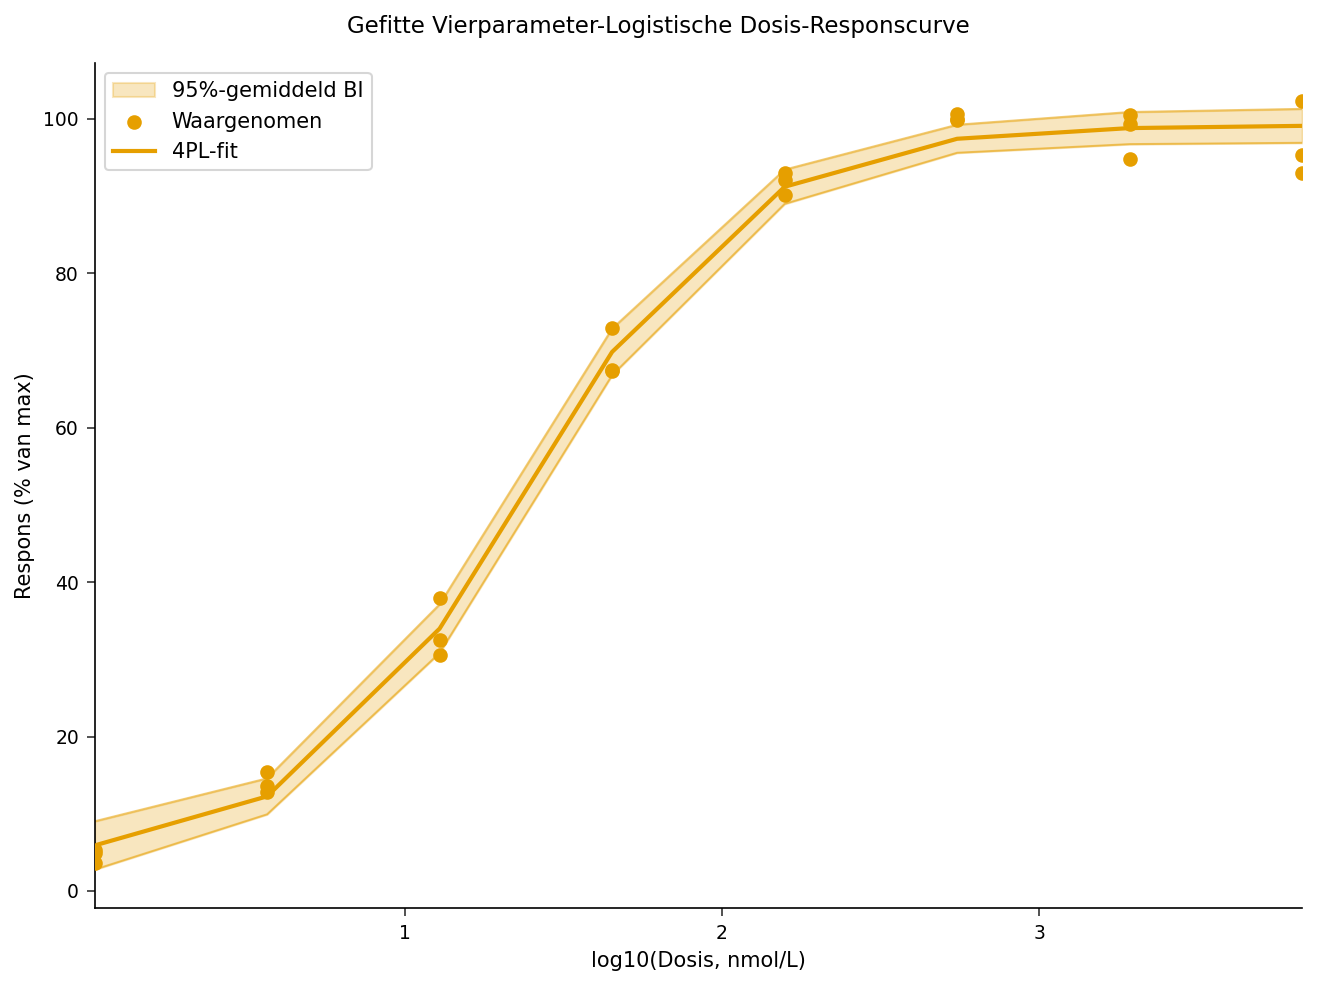

In [5]:
PROCEDURE SORTEREN GEGEVENS=fit4pl;
    VOLGENS logdose;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95%-gemiddeld BI';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Waargenomen';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='4PL-fit';
    XAXIS label='log10(Dosis, nmol/L)';
    YAXIS label='Respons (% van max)';
    TITEL 'Gefitte Vierparameter-Logistische Dosis-Responscurve';
UITVOEREN;
TITEL;


## De resultaten interpreteren

`PROC NLIN` convergeert naar schattingen die dicht bij de bekende genererende waarden liggen: een onderste asymptoot rond **5**, een bovenste asymptoot rond **100**, een **EC50 (C)** rond **25 nmol/L**, en een **Hill-helling (B)** rond **1.2**. Het terugvinden van deze parameters uit ruizige triplo-gegevens bevestigt dat het model identificeerbaar is en dat de grenzen niet bindend waren in het optimum.

De **EC50** is de belangrijkste potentiemaat: lagere waarden wijzen op een potentere verbinding, en in een relatieve-potentie-assay wordt de EC50 van een testlot vergeleken met een referentiestandaard. De **Hill-helling** karakteriseert coöperativiteit en de steilheid van de assay — een helling rond 1 is consistent met eenvoudige binding op één plaats. De **asymptoten** bepalen het dynamische bereik van de assay; een stabiele, goed gescheiden bottom en top zijn voorwaarden voor een valideerbare bioassay.

De fitplot toont de sigmoïde die door de wolk waargenomen punten loopt met een strakke 95%-gemiddelde betrouwbaarheidsband door het responsieve gebied, en de residudiagnostiek zou geen systematische kromming mogen tonen — bewijs dat de 4PL-vorm adequaat is. In de praktijk zou je deze workflow uitbreiden met `PROFILE`-likelihood-intervallen voor de EC50, een `BOOTSTRAP`-statement voor verdelingsvrije parameterinferentie, of een parallellijnenanalyse die test- en referentielots vergelijkt om de relatieve potentie te schatten.